In [30]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Define source file paths

aws_cur_path = "../synnepha_exercise_90d/synnepha_exercise_aws_cur_sample_90d.csv"
k8s_metrics_path = "../synnepha_exercise_90d/synnepha_exercise_k8s_metrics_90d.csv"

# Read source CSV files

aws_cur_df = pd.read_csv(aws_cur_path)
k8s_metrics_df = pd.read_csv(k8s_metrics_path)

print("AWS CUR shape:", aws_cur_df.shape)
print("K8s metrics shape:", k8s_metrics_df.shape)

AWS CUR shape: (8100, 8)
K8s metrics shape: (15120, 8)


In [3]:
# Check columns and data types

print("AWS CUR columns:")
print(aws_cur_df.columns.tolist())

print("\nK8s metrics columns:")
print(k8s_metrics_df.columns.tolist())

print("\nAWS CUR info:")
aws_cur_df.info()

print("\nK8s metrics info:")
k8s_metrics_df.info()

AWS CUR columns:
['billing_period', 'date', 'account_id', 'service', 'usage_type', 'region', 'cost_usd', 'usage_quantity']

K8s metrics columns:
['timestamp', 'pod_name', 'namespace', 'node', 'cpu_usage_cores', 'memory_usage_mb', 'cpu_request_cores', 'memory_request_mb']

AWS CUR info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   billing_period  8100 non-null   object 
 1   date            8100 non-null   object 
 2   account_id      8100 non-null   object 
 3   service         8100 non-null   object 
 4   usage_type      8100 non-null   object 
 5   region          8100 non-null   object 
 6   cost_usd        8100 non-null   float64
 7   usage_quantity  8100 non-null   float64
dtypes: float64(2), object(6)
memory usage: 506.4+ KB

K8s metrics info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data col

## Parse date columns

In [5]:
# Convert date columns into datetime format

aws_cur_df["date"] = pd.to_datetime(aws_cur_df["date"])

k8s_metrics_df["timestamp"] = pd.to_datetime(k8s_metrics_df["timestamp"])
k8s_metrics_df["date"] = k8s_metrics_df["timestamp"].dt.floor("D")

print("AWS date range:", aws_cur_df["date"].min(), "to", aws_cur_df["date"].max())
print("K8s date range:", k8s_metrics_df["date"].min(), "to", k8s_metrics_df["date"].max())

AWS date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00
K8s date range: 2026-01-31 00:00:00+00:00 to 2026-04-30 00:00:00+00:00


## Data quality checks

In [6]:
# Run basic data quality checks before anomaly detection

print("AWS CUR missing values:")
display(aws_cur_df.isna().sum())

print("K8s metrics missing values:")
display(k8s_metrics_df.isna().sum())

print("AWS duplicate rows:", aws_cur_df.duplicated().sum())
print("K8s duplicate rows:", k8s_metrics_df.duplicated().sum())

print("Negative cost rows:")
display(aws_cur_df[aws_cur_df["cost_usd"] < 0])

print("Negative usage rows:")
display(aws_cur_df[aws_cur_df["usage_quantity"] < 0])

AWS CUR missing values:


billing_period    0
date              0
account_id        0
service           0
usage_type        0
region            0
cost_usd          0
usage_quantity    0
dtype: int64

K8s metrics missing values:


timestamp            0
pod_name             0
namespace            0
node                 0
cpu_usage_cores      0
memory_usage_mb      0
cpu_request_cores    0
memory_request_mb    0
date                 0
dtype: int64

AWS duplicate rows: 0
K8s duplicate rows: 0
Negative cost rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity


Negative usage rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity


## Daily total cost aggregation

In [7]:
# Aggregate AWS cost at daily level

daily_cost_df = (
    aws_cur_df
    .groupby("date", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("date")
)

display(pd.concat([daily_cost_df.head(), daily_cost_df.tail()]))

,date,total_cost_usd,total_usage_quantity
0,2026-01-31,"16,862.60","133,458,592.40"
1,2026-02-01,"17,107.44","133,314,383.86"
2,2026-02-02,"24,095.45","211,286,400.58"
3,2026-02-03,"23,620.45","201,351,235.12"
4,2026-02-04,"23,736.00","209,291,301.51"
85,2026-04-26,"17,512.82","132,209,617.13"
86,2026-04-27,"23,640.68","201,351,198.82"
87,2026-04-28,"26,272.61","242,693,748.28"
88,2026-04-29,"27,743.61","235,347,154.37"
89,2026-04-30,"27,440.17","236,192,537.30"


## Daily cost anomaly detection

In [8]:
# Detect daily cost anomalies using rolling statistics and day-over-day change

daily_anomaly_df = daily_cost_df.copy()

daily_anomaly_df["rolling_mean_14d"] = (
    daily_anomaly_df["total_cost_usd"]
    .rolling(window=14, min_periods=7)
    .mean()
)

daily_anomaly_df["rolling_std_14d"] = (
    daily_anomaly_df["total_cost_usd"]
    .rolling(window=14, min_periods=7)
    .std()
)

daily_anomaly_df["z_score"] = (
    daily_anomaly_df["total_cost_usd"] - daily_anomaly_df["rolling_mean_14d"]
) / daily_anomaly_df["rolling_std_14d"]

daily_anomaly_df["cost_diff_abs"] = daily_anomaly_df["total_cost_usd"].diff()
daily_anomaly_df["cost_diff_pct"] = daily_anomaly_df["total_cost_usd"].pct_change() * 100

daily_anomalies = (
    daily_anomaly_df[
        (daily_anomaly_df["z_score"].abs() >= 3) |
        (daily_anomaly_df["cost_diff_pct"] >= 50)
    ]
    .sort_values("total_cost_usd", ascending=False)
)

display(daily_anomalies)

,date,total_cost_usd,total_usage_quantity,rolling_mean_14d,rolling_std_14d,z_score,cost_diff_abs,cost_diff_pct
73,2026-04-14,"45,023.11","199,975,099.80","23,254.14","6,916.43",3.15,"20,894.66",86.60


## Plot daily cost anomalies

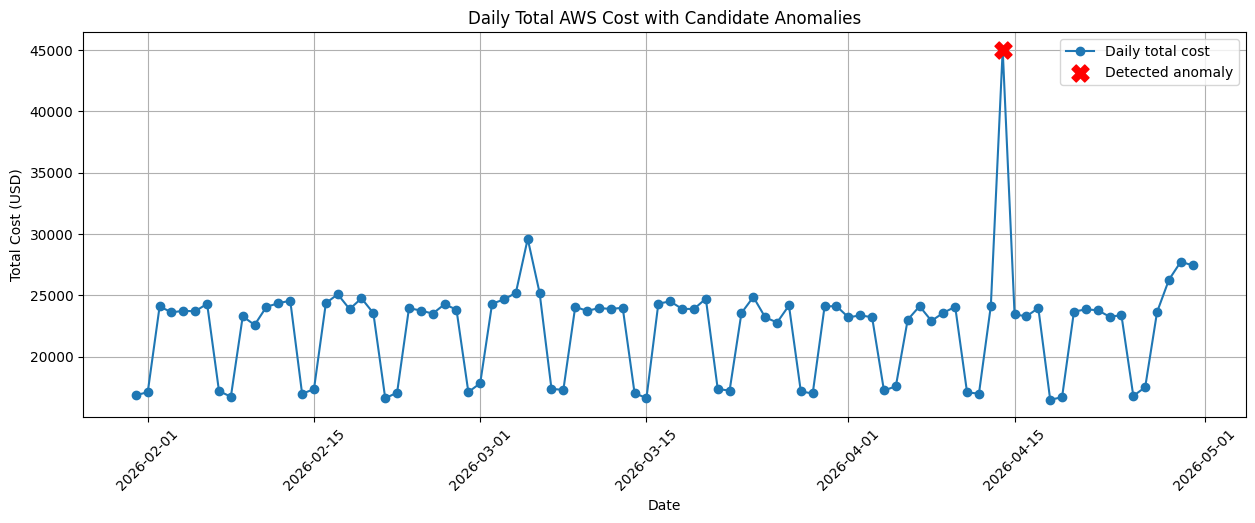

In [10]:
# Visualize daily cost and candidate anomalies

plt.figure(figsize=(15, 5))

# Normal daily cost line
plt.plot(
    daily_anomaly_df["date"],
    daily_anomaly_df["total_cost_usd"],
    marker="o",
    label="Daily total cost"
)

# Highlight anomaly points in red
plt.scatter(
    daily_anomalies["date"],
    daily_anomalies["total_cost_usd"],
    color="red",
    s=150,
    marker="X",
    label="Detected anomaly",
    zorder=10
)

plt.title("Daily Total AWS Cost with Candidate Anomalies")
plt.xlabel("Date")
plt.ylabel("Total Cost (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Group-level anomaly detection

In [11]:
# Detect anomalies at account-service-usage_type-region level

group_cols = ["account_id", "service", "usage_type", "region"]

group_daily_df = (
    aws_cur_df
    .groupby(["date"] + group_cols, as_index=False)
    .agg(
        cost_usd=("cost_usd", "sum"),
        usage_quantity=("usage_quantity", "sum")
    )
    .sort_values(group_cols + ["date"])
)

group_daily_df["group_mean"] = (
    group_daily_df
    .groupby(group_cols)["cost_usd"]
    .transform("mean")
)

group_daily_df["group_std"] = (
    group_daily_df
    .groupby(group_cols)["cost_usd"]
    .transform("std")
)

group_daily_df["z_score"] = (
    group_daily_df["cost_usd"] - group_daily_df["group_mean"]
) / group_daily_df["group_std"]

group_anomalies = (
    group_daily_df[
        group_daily_df["z_score"].abs() >= 3
    ]
    .sort_values("cost_usd", ascending=False)
)

display(group_anomalies.head(30))

,date,account_id,service,usage_type,region,cost_usd,usage_quantity,group_mean,group_std,z_score
6575,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57","1,449.77","1,243.69",8.98
6574,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"11,950.07","62,239.98","1,368.49","1,231.10",8.60
3775,2026-03-13,acct_008,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,339.99,"1,421.21",267.52,23.03,3.15
6523,2026-04-13,acct_005,AWSLambda,Lambda-GB-Second,us-west-2,316.40,"18,983,678.12",112.37,55.22,3.70
6522,2026-04-13,acct_005,AWSLambda,Lambda-GB-Second,us-east-1,293.07,"17,583,971.97",107.83,48.38,3.83
8044,2026-04-30,acct_003,AmazonS3,TimedStorage-ByteHrs,us-east-1,171.42,"7,452,967.05",72.48,20.04,4.94
8043,2026-04-30,acct_003,AmazonS3,TimedStorage-ByteHrs,eu-central-1,169.40,"7,365,648.40",73.86,20.42,4.68
8045,2026-04-30,acct_003,AmazonS3,TimedStorage-ByteHrs,us-west-2,167.89,"7,300,096.56",74.00,20.12,4.67
7955,2026-04-29,acct_003,AmazonS3,TimedStorage-ByteHrs,us-west-2,155.80,"6,773,655.66",74.00,20.12,4.07
7953,2026-04-29,acct_003,AmazonS3,TimedStorage-ByteHrs,eu-central-1,154.63,"6,723,215.35",73.86,20.42,3.96


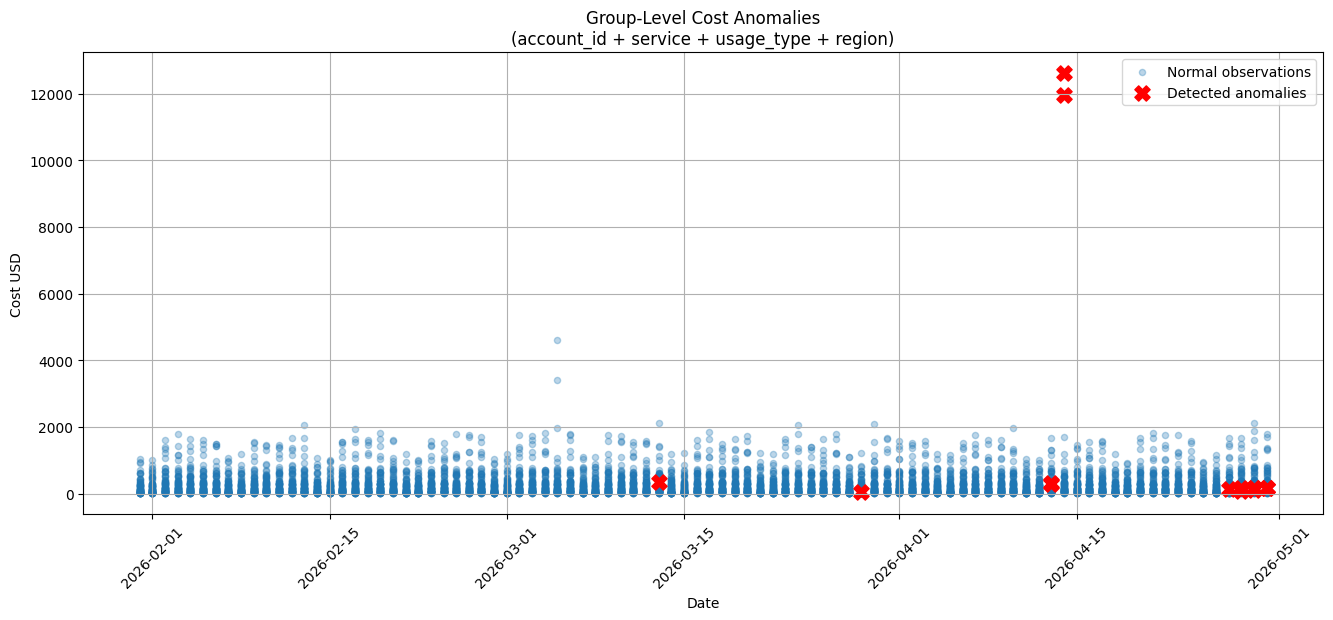

In [12]:
# Plot group-level anomalies

plt.figure(figsize=(16, 6))

# Plot all group-level observations
plt.scatter(
    group_daily_df["date"],
    group_daily_df["cost_usd"],
    alpha=0.3,
    s=20,
    label="Normal observations"
)

# Highlight anomalies in red
plt.scatter(
    group_anomalies["date"],
    group_anomalies["cost_usd"],
    color="red",
    marker="X",
    s=120,
    label="Detected anomalies"
)

plt.title(
    "Group-Level Cost Anomalies\n(account_id + service + usage_type + region)"
)
plt.xlabel("Date")
plt.ylabel("Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Root-cause inspection for largest daily anomaly

In [13]:
# Select the largest daily anomaly date for root-cause analysis

target_date = daily_anomalies.iloc[0]["date"]

print("Selected anomaly date:", target_date)

root_cause_df = (
    aws_cur_df[aws_cur_df["date"] == target_date]
    .sort_values("cost_usd", ascending=False)
)

display(root_cause_df.head(20))

Selected anomaly date: 2026-04-14 00:00:00


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
6570,2026-04,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57"
6571,2026-04,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"11,950.07","62,239.98"
6582,2026-04,2026-04-14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,698.60","8,846.89"
6613,2026-04,2026-04-14,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,176.60","6,128.14"
6612,2026-04,2026-04-14,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,970.90,"5,056.79"
6584,2026-04,2026-04-14,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,701.48,"2,922.84"
6575,2026-04,2026-04-14,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,646.79,"2,694.97"
6574,2026-04,2026-04-14,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,631.27,"2,630.29"
6630,2026-04,2026-04-14,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,594.85,"3,098.19"
6631,2026-04,2026-04-14,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,532.71,"2,774.53"


## Service-level contribution on anomaly day

In [15]:
# Analyze service contribution on the anomaly day

service_contribution_df = (
    root_cause_df
    .groupby("service", as_index=False)
    .agg(total_cost_usd=("cost_usd", "sum"))
    .sort_values("total_cost_usd", ascending=False)
)

service_contribution_df["cost_share_pct"] = (
    service_contribution_df["total_cost_usd"] /
    service_contribution_df["total_cost_usd"].sum()
) * 100

display(service_contribution_df)

,service,total_cost_usd,cost_share_pct
2,AmazonEC2,"32,722.67",72.68
4,AmazonRDS,"5,223.83",11.60
5,AmazonS3,"2,824.89",6.27
3,AmazonEKS,"2,401.82",5.33
0,AWSLambda,"1,282.27",2.85
1,AmazonCloudWatch,567.62,1.26


## Account-service-region contribution on anomaly day

In [16]:
# Analyze detailed cost contribution on the anomaly day

detailed_contribution_df = (
    root_cause_df
    .groupby(["account_id", "service", "usage_type", "region"], as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("total_cost_usd", ascending=False)
)

detailed_contribution_df["cost_share_pct"] = (
    detailed_contribution_df["total_cost_usd"] /
    detailed_contribution_df["total_cost_usd"].sum()
) * 100

display(detailed_contribution_df.head(20))

,account_id,service,usage_type,region,total_cost_usd,total_usage_quantity,cost_share_pct
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57",28.01
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"11,950.07","62,239.98",26.54
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,698.60","8,846.89",3.77
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,176.60","6,128.14",2.61
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,970.90,"5,056.79",2.16
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,701.48,"2,922.84",1.56
8,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,646.79,"2,694.97",1.44
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,631.27,"2,630.29",1.40
65,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,594.85,"3,098.19",1.32
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,532.71,"2,774.53",1.18


## Kubernetes utilization features

In [17]:
# Create Kubernetes CPU and memory utilization ratios

k8s_metrics_df["cpu_utilization_ratio"] = (
    k8s_metrics_df["cpu_usage_cores"] / k8s_metrics_df["cpu_request_cores"]
)

k8s_metrics_df["memory_utilization_ratio"] = (
    k8s_metrics_df["memory_usage_mb"] / k8s_metrics_df["memory_request_mb"]
)

k8s_metrics_df.replace([np.inf, -np.inf], np.nan, inplace=True)

display(k8s_metrics_df.head())

,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date,cpu_utilization_ratio,memory_utilization_ratio
0,2026-01-31 00:00:00+00:00,api-gateway-7f8d9,production,node-01,0.13,199.10,0.50,512,2026-01-31 00:00:00+00:00,0.27,0.39
1,2026-01-31 00:00:00+00:00,batch-processor-1d5f3,production,node-01,0.38,976.10,1.00,2048,2026-01-31 00:00:00+00:00,0.38,0.48
2,2026-01-31 00:00:00+00:00,cache-layer-5f1d9,production,node-01,0.24,484.10,0.50,1024,2026-01-31 00:00:00+00:00,0.47,0.47
3,2026-01-31 00:00:00+00:00,data-pipeline-4a2c1,production,node-02,0.78,"1,912.10",2.00,4096,2026-01-31 00:00:00+00:00,0.39,0.47
4,2026-01-31 00:00:00+00:00,legacy-etl-2e7b4,production,node-03,0.05,86.20,2.00,4096,2026-01-31 00:00:00+00:00,0.02,0.02


## Daily Kubernetes aggregation

In [21]:
# Remove timezone information from Kubernetes date column

k8s_metrics_df["timestamp"] = (
    pd.to_datetime(k8s_metrics_df["timestamp"])
    .dt.tz_localize(None)
)

k8s_metrics_df["date"] = (
    k8s_metrics_df["timestamp"]
    .dt.floor("D")
)

In [22]:
# Aggregate Kubernetes metrics at daily level

daily_k8s_df = (
    k8s_metrics_df
    .groupby("date", as_index=False)
    .agg(
        avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        max_cpu_usage_cores=("cpu_usage_cores", "max"),
        avg_memory_usage_mb=("memory_usage_mb", "mean"),
        max_memory_usage_mb=("memory_usage_mb", "max"),
        avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
        max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
        avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
        max_memory_utilization_ratio=("memory_utilization_ratio", "max")
    )
)

In [23]:
print(daily_anomaly_df["date"].dtype)
print(daily_k8s_df["date"].dtype)

datetime64[ns]
datetime64[ns]


## Join AWS cost and K8s metrics

In [25]:
# Join daily AWS cost with daily Kubernetes metrics

daily_combined_df = daily_anomaly_df.merge(
    daily_k8s_df,
    on="date",
    how="left"
)

display(daily_combined_df.head(30))

,date,total_cost_usd,total_usage_quantity,rolling_mean_14d,rolling_std_14d,z_score,cost_diff_abs,cost_diff_pct,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
0,2026-01-31,"16,862.60","133,458,592.40",NaN,NaN,NaN,NaN,NaN,0.51,2.93,"1,063.38","4,279.80",0.36,0.73,0.41,0.66
1,2026-02-01,"17,107.44","133,314,383.86",NaN,NaN,NaN,244.84,1.45,0.47,2.39,"1,062.49","4,744.00",0.33,0.68,0.41,0.73
2,2026-02-02,"24,095.45","211,286,400.58",NaN,NaN,NaN,"6,988.01",40.85,0.69,3.72,"1,514.90","7,818.40",0.49,1.15,0.57,1.25
3,2026-02-03,"23,620.45","201,351,235.12",NaN,NaN,NaN,-475.00,-1.97,0.72,4.52,"1,507.49","7,465.20",0.49,1.13,0.57,1.14
4,2026-02-04,"23,736.00","209,291,301.51",NaN,NaN,NaN,115.55,0.49,0.68,3.66,"1,503.40","7,173.20",0.48,1.10,0.57,1.14
5,2026-02-05,"23,705.73","199,735,094.95",NaN,NaN,NaN,-30.27,-0.13,0.73,3.84,"1,503.52","7,398.20",0.51,1.18,0.57,1.05
6,2026-02-06,"24,314.63","196,956,297.63","21,920.33","3,380.90",0.71,608.90,2.57,0.70,3.79,"1,496.76","7,797.20",0.49,1.04,0.57,1.08
7,2026-02-07,"17,201.58","127,830,595.29","21,330.49","3,546.96",-1.16,"-7,113.05",-29.25,0.52,2.52,"1,080.40","4,226.60",0.36,0.66,0.40,0.67
8,2026-02-08,"16,734.99","128,425,793.57","20,819.87","3,654.42",-1.12,-466.59,-2.71,0.52,2.55,"1,098.79","4,529.00",0.36,0.86,0.42,0.68
9,2026-02-09,"23,290.79","199,916,458.17","21,066.97","3,532.91",0.63,"6,555.80",39.17,0.71,4.74,"1,488.18","7,105.70",0.50,1.18,0.56,1.03


## Correlation analysis

In [26]:
# Analyze relationship between AWS cost and Kubernetes utilization metrics

correlation_cols = [
    "total_cost_usd",
    "total_usage_quantity",
    "avg_cpu_usage_cores",
    "max_cpu_usage_cores",
    "avg_memory_usage_mb",
    "max_memory_usage_mb",
    "avg_cpu_utilization_ratio",
    "max_cpu_utilization_ratio",
    "avg_memory_utilization_ratio",
    "max_memory_utilization_ratio"
]

correlation_result = (
    daily_combined_df[correlation_cols]
    .corr()["total_cost_usd"]
    .sort_values(ascending=False)
)

display(correlation_result)

total_cost_usd                 1.00
avg_cpu_usage_cores            0.95
max_memory_usage_mb            0.95
avg_cpu_utilization_ratio      0.93
avg_memory_usage_mb            0.93
max_cpu_utilization_ratio      0.91
max_memory_utilization_ratio   0.91
max_cpu_usage_cores            0.88
avg_memory_utilization_ratio   0.87
total_usage_quantity           0.81
Name: total_cost_usd, dtype: float64

## Kubernetes metrics on anomaly day

In [27]:
# Inspect Kubernetes pod-level metrics on the anomaly day

k8s_anomaly_day_df = k8s_metrics_df[k8s_metrics_df["date"] == target_date]

pod_anomaly_summary_df = (
    k8s_anomaly_day_df
    .groupby("pod_name", as_index=False)
    .agg(
        avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        max_cpu_usage_cores=("cpu_usage_cores", "max"),
        avg_memory_usage_mb=("memory_usage_mb", "mean"),
        max_memory_usage_mb=("memory_usage_mb", "max"),
        avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
        max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
        avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
        max_memory_utilization_ratio=("memory_utilization_ratio", "max")
    )
    .sort_values("max_cpu_usage_cores", ascending=False)
)

display(pod_anomaly_summary_df)

,pod_name,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
5,model-serving-9b3e7,8.10,12.76,"9,000.13","13,530.60",2.02,3.19,1.10,1.65
3,data-pipeline-4a2c1,1.17,1.99,"2,641.63","3,946.50",0.59,0.99,0.64,0.96
1,batch-processor-1d5f3,0.58,0.89,"1,384.81","2,057.60",0.58,0.89,0.68,1.00
2,cache-layer-5f1d9,0.33,0.58,756.19,"1,107.00",0.66,1.16,0.74,1.08
0,api-gateway-7f8d9,0.31,0.44,374.80,588.80,0.61,0.87,0.73,1.15
6,monitoring-agent-6c8a2,0.15,0.22,179.07,269.30,0.59,0.88,0.70,1.05
4,legacy-etl-2e7b4,0.08,0.14,116.28,167.90,0.04,0.07,0.03,0.04


## Forecast model

In [31]:
# Build a simple daily cost forecast using Holt-Winters Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_df = (
    daily_cost_df[["date", "total_cost_usd"]]
    .copy()
    .set_index("date")
    .asfreq("D")
)

hw_model = ExponentialSmoothing(
    forecast_df["total_cost_usd"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = hw_model.fit(optimized=True)

forecast_horizon = 14
forecast_values = hw_fit.forecast(forecast_horizon)

forecast_result_df = pd.DataFrame({
    "date": forecast_values.index,
    "forecast_total_cost_usd": forecast_values.values
})

display(forecast_result_df)

,date,forecast_total_cost_usd
0,2026-05-01,"24,660.21"
1,2026-05-02,"17,621.06"
2,2026-05-03,"17,752.70"
3,2026-05-04,"24,493.99"
4,2026-05-05,"26,458.18"
5,2026-05-06,"24,647.10"
6,2026-05-07,"25,091.28"
7,2026-05-08,"24,749.55"
8,2026-05-09,"17,710.40"
9,2026-05-10,"17,842.04"


## Forecast visualization

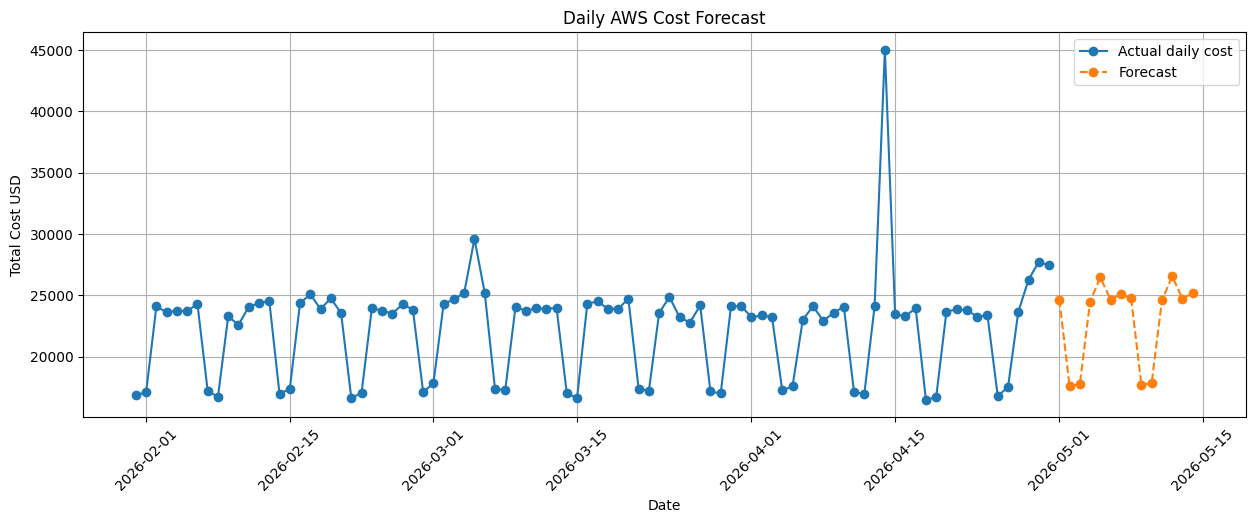

In [32]:
# Visualize actual daily cost and forecasted values

plt.figure(figsize=(15, 5))

plt.plot(
    forecast_df.index,
    forecast_df["total_cost_usd"],
    marker="o",
    label="Actual daily cost"
)

plt.plot(
    forecast_result_df["date"],
    forecast_result_df["forecast_total_cost_usd"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Daily AWS Cost Forecast")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Save outputs

In [33]:
# Save result tables for documentation and final reporting

daily_anomaly_df.to_csv("../synnepha_exercise_90d/results/daily_anomaly_detection_results.csv", index=False)
daily_anomalies.to_csv("../synnepha_exercise_90d/results/candidate_daily_anomalies.csv", index=False)
group_anomalies.to_csv("../synnepha_exercise_90d/results/candidate_group_level_anomalies.csv", index=False)
daily_combined_df.to_csv("../synnepha_exercise_90d/results/daily_cost_k8s_combined.csv", index=False)
forecast_result_df.to_csv("../synnepha_exercise_90d/results/daily_cost_forecast.csv", index=False)

print("Output files saved successfully.")

Output files saved successfully.


## Final candidate anomaly summary

In [34]:
# Create a compact summary of the most important candidate anomalies

candidate_summary = {
    "anomaly_1": {
        "type": "Daily total cost spike",
        "date": str(target_date.date()),
        "method": "Rolling z-score and day-over-day percentage increase",
        "description": "The total daily AWS cost increased significantly compared to recent historical behavior."
    },
    "anomaly_2": {
        "type": "Account-service-region cost spike",
        "date": str(target_date.date()),
        "method": "Grouped z-score by account_id, service, usage_type, and region",
        "description": "The largest contributors on the anomaly day were concentrated in specific EC2 usage dimensions."
    },
    "anomaly_3": {
        "type": "Workload-driven infrastructure anomaly",
        "date": str(target_date.date()),
        "method": "Correlation and joint inspection of AWS cost and Kubernetes CPU/memory metrics",
        "description": "The cost spike aligns with increased Kubernetes resource usage, suggesting a workload-related cost increase."
    }
}

candidate_summary

{'anomaly_1': {'type': 'Daily total cost spike',
  'date': '2026-04-14',
  'method': 'Rolling z-score and day-over-day percentage increase',
  'description': 'The total daily AWS cost increased significantly compared to recent historical behavior.'},
 'anomaly_2': {'type': 'Account-service-region cost spike',
  'date': '2026-04-14',
  'method': 'Grouped z-score by account_id, service, usage_type, and region',
  'description': 'The largest contributors on the anomaly day were concentrated in specific EC2 usage dimensions.'},
 'anomaly_3': {'type': 'Workload-driven infrastructure anomaly',
  'date': '2026-04-14',
  'method': 'Correlation and joint inspection of AWS cost and Kubernetes CPU/memory metrics',
  'description': 'The cost spike aligns with increased Kubernetes resource usage, suggesting a workload-related cost increase.'}}

In [37]:
summary_df = pd.DataFrame({
    "Anomaly": [
        "Daily Cost Spike",
        "EC2 Cost Spike",
        "Kubernetes Load Spike"
    ],
    "Detection Method": [
        "Rolling Z-Score + DoD Change",
        "Grouped Z-Score",
        "Cost vs K8s Correlation"
    ],
    "Date": [
        str(target_date.date()),
        str(target_date.date()),
        str(target_date.date())
    ],
    "Description": [
        "Total AWS cost increased significantly versus baseline.",
        "EC2 spending concentrated in specific account-region combinations.",
        "Cost increase aligned with higher CPU and memory utilization."
    ]
})

summary_df.style\
    .hide(axis="index")\
    .set_caption("Candidate Cost Anomalies")\
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })

Anomaly,Detection Method,Date,Description
Daily Cost Spike,Rolling Z-Score + DoD Change,2026-04-14,Total AWS cost increased significantly versus baseline.
EC2 Cost Spike,Grouped Z-Score,2026-04-14,EC2 spending concentrated in specific account-region combinations.
Kubernetes Load Spike,Cost vs K8s Correlation,2026-04-14,Cost increase aligned with higher CPU and memory utilization.
